### Imports

In [96]:
import random
import operator

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from deap import base
from deap import creator
from deap import tools
from deap import gp

from sklearn.model_selection import train_test_split

### Datasets

In [97]:
# Read in our csv files downloaded from Kaggle
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

random.seed(100)
np.random.seed(100)

train_data.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
train_data.set_index(keys=['PassengerId'], drop=True, inplace=True)

test_data.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)
test_data.set_index(keys=['PassengerId'], drop=True, inplace=True)

train_nan_map = {'Age': train_data['Age'].mean(), 'Fare': train_data['Fare'].mean(), 'Embarked': train_data['Embarked'].mode()[0]}
test_nan_map = {'Age': test_data['Age'].mean(), 'Fare': test_data['Fare'].mean(), 'Embarked': test_data['Embarked'].mode()[0]}

train_data.fillna(value=train_nan_map, inplace=True)
test_data.fillna(value=test_nan_map, inplace=True)

columns_map = {'Embarked': {'C': 0, 'Q': 1, 'S': 2}, 'Sex': {'male': 0, 'female': 1}}
# Adding below line to surpress deprication warnings
pd.set_option('future.no_silent_downcasting', True)
train_data.replace(columns_map, inplace=True)
test_data.replace(columns_map, inplace=True)

X_train = train_data.loc[:, train_data.columns != 'Survived']
y_train = train_data.loc[:, 'Survived']

print(train_data.head())

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.33, random_state=100)

             Survived  Pclass Sex   Age  SibSp  Parch     Fare Embarked
PassengerId                                                            
1                   0       3   0  22.0      1      0   7.2500        2
2                   1       1   1  38.0      1      0  71.2833        0
3                   1       3   1  26.0      0      0   7.9250        2
4                   1       1   1  35.0      1      0  53.1000        2
5                   0       3   0  35.0      0      0   8.0500        2


/var/folders/ck/k3xlx_417p77nqyjfb7klv6w0000gn/T/ipykernel_64665/2493623981.py:22: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [98]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

/opt/anaconda3/envs/emade/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/opt/anaconda3/envs/emade/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


### Strongly Typed GP

In [99]:
pset = gp.PrimitiveSetTyped(
    "MAIN",
    [float, float, float, float, float, float, float],
    bool
)

pset.renameArguments(
    ARG0="Pclass",
    ARG1="Sex",
    ARG2="Age",
    ARG3="SibSp",
    ARG4="Parch",
    ARG5="Fare",
    ARG6="Embarked"
)

pset.addPrimitive(operator.lt, [float, float], bool)
pset.addPrimitive(operator.gt, [float, float], bool)
pset.addPrimitive(operator.le, [float, float], bool)
pset.addPrimitive(operator.ge, [float, float], bool)

pset.addPrimitive(operator.and_, [bool, bool], bool)
pset.addPrimitive(operator.or_, [bool, bool], bool)
pset.addPrimitive(operator.not_, [bool], bool)

pset.addPrimitive(operator.add, [float, float], float)
pset.addPrimitive(operator.sub, [float, float], float)
pset.addPrimitive(operator.mul, [float, float], float)

pset.addTerminal(True, bool)
pset.addTerminal(False, bool)

pset.addEphemeralConstant(
    "rand_float",
    lambda: random.uniform(0, 100),
    float
)

/opt/anaconda3/envs/emade/lib/python3.13/site-packages/deap/gp.py:257: RuntimeWarning: Ephemeral rand_float function cannot be pickled because its generating function is a lambda function. Use functools.partial instead.
  warnings.warn("Ephemeral {name} function cannot be "


### Evaluation Function

#### This compares the result of the tree evaluation to the actual result from the dataset

In [100]:
def evaluate(individual):
    func = gp.compile(expr=individual, pset=pset)

    predictions = []

    for i in range(len(X_train)):
        row = X_train.iloc[i]

        prediction = func(
            row["Pclass"],
            row["Sex"],
            row["Age"],
            row["SibSp"],
            row["Parch"],
            row["Fare"],
            row["Embarked"]
        )

        predictions.append(int(prediction))

    y_true = y_train.to_numpy()
    y_pred = np.array(predictions)

    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TP = np.sum((y_true == 1) & (y_pred == 1))

    fpr = FP / (FP + TN)
    fnr = FN / (FN + TP)

    return fpr, fnr

### Register the toolbox

In [101]:
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=2)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)
toolbox.register("evaluate", evaluate)

toolbox.register("select", tools.selNSGA2)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=1, max_=4)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

In [102]:
individual = toolbox.individual()

print(individual)
print(toolbox.evaluate(individual))

ge(add(Embarked, Fare), Sex)
(np.float64(1.0), np.float64(0.0))


In [103]:
print(pset.primitives)
print(pset.terminals)

defaultdict(<class 'list'>, {<class 'float'>: [<deap.gp.Primitive object at 0x147196de0>, <deap.gp.Primitive object at 0x147196c50>, <deap.gp.Primitive object at 0x147196bb0>], <class 'bool'>: [<deap.gp.Primitive object at 0x145e5e930>, <deap.gp.Primitive object at 0x147196f70>, <deap.gp.Primitive object at 0x147196e30>, <deap.gp.Primitive object at 0x147194a40>, <deap.gp.Primitive object at 0x147196d40>, <deap.gp.Primitive object at 0x147196cf0>, <deap.gp.Primitive object at 0x147196ca0>]})
defaultdict(<class 'list'>, {<class 'float'>: [<deap.gp.Terminal object at 0x145dd0a80>, <deap.gp.Terminal object at 0x145dd1f80>, <deap.gp.Terminal object at 0x145dd26c0>, <deap.gp.Terminal object at 0x145dd1040>, <deap.gp.Terminal object at 0x145dd3b40>, <deap.gp.Terminal object at 0x145dd1cc0>, <deap.gp.Terminal object at 0x145dd2200>, <class 'deap.gp.rand_float'>], <class 'bool'>: [<deap.gp.Terminal object at 0x1447ffa80>, <deap.gp.Terminal object at 0x145dd3480>]})


### Evolutionary Loop

In [104]:
NUM_GENERATIONS = 40
POPULATION_SIZE = 300

pop = toolbox.population(n=POPULATION_SIZE)

# Evaluate initial population
for ind in pop:
    ind.fitness.values = toolbox.evaluate(ind)

# Evolution
for g in range(NUM_GENERATIONS):

    print(f"-- Generation {g} --")

    # Select parents
    offspring = toolbox.select(pop, len(pop))

    # Clone parents so we don't modify the original population
    offspring = list(map(toolbox.clone, offspring))

    # Crossover
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.5:
            toolbox.mate(child1, child2)

            del child1.fitness.values
            del child2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() < 0.2:
            toolbox.mutate(mutant)

            del mutant.fitness.values

    # Evaluate individuals whose fitness was changed
    invalid_ind = [
        ind for ind in offspring
        if not ind.fitness.valid
    ]

    for ind in invalid_ind:
        ind.fitness.values = toolbox.evaluate(ind)

    # Combine parents and offspring
    combined = pop + offspring

    # NSGA-II selects the next generation
    pop = toolbox.select(combined, POPULATION_SIZE)

pareto_front = tools.sortNondominated(
    pop,
    len(pop),
    first_front_only=True
)[0]

print("\nPareto Front:")
for ind in pareto_front:
    print(ind, ind.fitness.values)

-- Generation 0 --
-- Generation 1 --
-- Generation 2 --
-- Generation 3 --
-- Generation 4 --
-- Generation 5 --
-- Generation 6 --
-- Generation 7 --
-- Generation 8 --
-- Generation 9 --
-- Generation 10 --
-- Generation 11 --
-- Generation 12 --
-- Generation 13 --
-- Generation 14 --
-- Generation 15 --
-- Generation 16 --
-- Generation 17 --
-- Generation 18 --
-- Generation 19 --
-- Generation 20 --
-- Generation 21 --
-- Generation 22 --
-- Generation 23 --
-- Generation 24 --
-- Generation 25 --
-- Generation 26 --
-- Generation 27 --
-- Generation 28 --
-- Generation 29 --
-- Generation 30 --
-- Generation 31 --
-- Generation 32 --
-- Generation 33 --
-- Generation 34 --
-- Generation 35 --
-- Generation 36 --
-- Generation 37 --
-- Generation 38 --
-- Generation 39 --

Pareto Front:
lt(mul(SibSp, SibSp), add(add(SibSp, 7.99417725388567), mul(Pclass, Parch))) (np.float64(0.9628647214854111), np.float64(0.0))
lt(mul(SibSp, SibSp), add(add(SibSp, 7.99417725388567), mul(Pclass, 

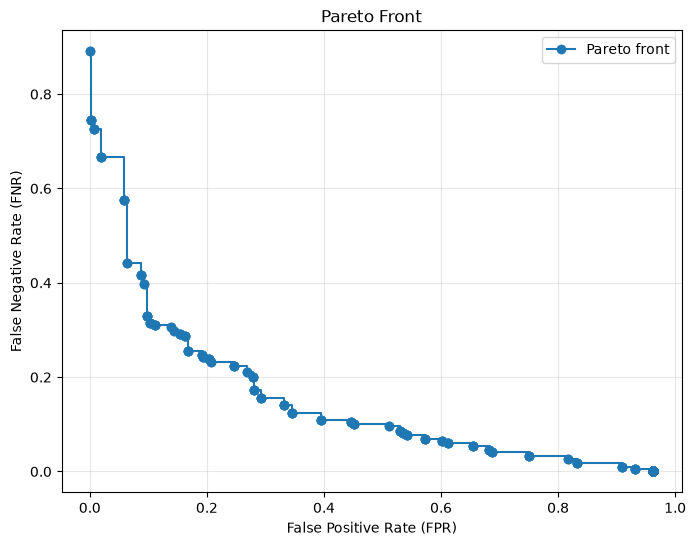

In [108]:
pareto_points = np.array([
    ind.fitness.values for ind in pareto_front
])

# Sort by FPR
pareto_points = pareto_points[
    np.argsort(pareto_points[:, 0])
]

plt.figure(figsize=(8, 6))

# Pareto-optimal points
plt.scatter(
    pareto_points[:, 0],
    pareto_points[:, 1],
    marker='o'
)

# Step-shaped Pareto front
plt.plot(
    pareto_points[:, 0],
    pareto_points[:, 1],
    linestyle='-',
    marker='o',
    drawstyle='steps-post',
    label='Pareto front'
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("False Negative Rate (FNR)")
plt.title("Pareto Front")
plt.legend()
plt.grid(alpha=0.3)
plt.show()